### Full FRIDA dataset analysis

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path


plt.style.use("seaborn-v0_8")

In [2]:
# Convert binary simulation results to H5

import os
import numpy as np
import h5py
import csv

# -------------------------------
# Configuration
# -------------------------------
IMG_LEN = 2234   # <-- set to your real value

# Input binary directory
OUTDIR = "../Hardware/vitis/DeepWaveAccel/output"

pixels_file = os.path.join(OUTDIR, "deepwave_pixels.bin")
norms_file  = os.path.join(OUTDIR, "deepwave_norms.bin")
index_file  = os.path.join(OUTDIR, "deepwave_index.csv")

# Output directory for H5 (relative to script)
OUTPUT_DIR = "data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

h5_output = os.path.join(OUTPUT_DIR, "deepwave_csim_results.h5")


# -------------------------------
# Load binary data
# -------------------------------
pixels_flat = np.fromfile(pixels_file, dtype=np.float32)
norms_flat  = np.fromfile(norms_file,  dtype=np.float32)

print("Loaded pixels:", pixels_flat.shape)
print("Loaded norms :", norms_flat.shape)


# -------------------------------
# Helper: convert "1-5.wav" → "s1_5"
# -------------------------------
def wavname_to_group(name):
    base = os.path.basename(name)
    noext = os.path.splitext(base)[0]    # “1-5”
    parts = noext.split('-')             # ["1","5"]
    parts = sorted(parts, key=int)
    return "s" + "_".join(parts)


# -------------------------------
# Write HDF5
# -------------------------------
with h5py.File(h5_output, "w") as h5:
    
    # Create main groups
    grp1 = h5.create_group("one_speaker")
    grp2 = h5.create_group("two_speakers")
    grp3 = h5.create_group("three_speakers")

    with open(index_file, "r") as f:
        reader = csv.DictReader(f)

        for row in reader:
            wav_rel = row["wav"]            # "one_speaker/1.wav"
            start   = int(row["start_frame"])
            frames  = int(row["frames"])

            # Category (one_speaker, ...)
            folder = wav_rel.split("/")[0]

            # Name conversion for speakers
            group_name = wavname_to_group(wav_rel)

            # Select parent group
            if folder == "one_speaker":
                parent = grp1
            elif folder == "two_speakers":
                parent = grp2
            else:
                parent = grp3

            # Create subgroup
            subgrp = parent.create_group(group_name)

            # Slice pixel buffer
            px_start = start * IMG_LEN
            px_end   = (start + frames) * IMG_LEN
            px = pixels_flat[px_start:px_end].reshape(frames, IMG_LEN)

            # Norm slice
            nm = norms_flat[start:start + frames]

            # Store datasets
            subgrp.create_dataset("pixels", data=px, compression="gzip")
            subgrp.create_dataset("norms",  data=nm, compression="gzip")

print("DONE →", h5_output)


Loaded pixels: (6165840,)
Loaded norms : (2760,)
DONE → data\deepwave_csim_results.h5


In [3]:
# Helper functions

def list_recordings(h5file, group):
    return list(h5file[group].keys())


In [4]:
# Import simulation results

BASE = Path("data")   # adjust if needed

FILE_CSIM = BASE / "deepwave_csim_results.h5"
FILE_HW   = BASE / "deepwave_hw_results.h5"
FILE_REF  = BASE / "deepwave_ref_results.h5"

f_csim = h5py.File(FILE_CSIM, "r")
f_hw   = h5py.File(FILE_HW, "r")
f_ref  = h5py.File(FILE_REF, "r")

groups = ["one_speaker", "two_speakers", "three_speakers"]


In [5]:
# Frame filtering

def get_filtered_frames(f_ref, f_csim, group, rec):
    ref_grp = f_ref[group][rec]

    # Load both norms correctly
    norms_energy = ref_grp["norms_energy"][:]     # base energy norm
    norms_eigen  = ref_grp["norms_eigen"][:]      # eigenvalue-based norm

    # Load pixel data (use energy-based as reference)
    pix_energy  = ref_grp["pixels_energy"][:]     # reference images
    pix_csim    = f_csim[group][rec]["pixels"][:] # your C-Sim output

    # Frame selection (based on energy norm)
    mask = norms_energy >= 1.0

    return (
        pix_energy[mask],     # reference pixels
        pix_csim[mask],       # C-sim pixels
        norms_energy[mask],   # filtered energy norms
        norms_eigen[mask]     # filtered eigen norms
    )



In [6]:
# Metric computation

def mse(a, b):
    return np.mean((a - b)**2, axis=1)

def mae(a, b):
    return np.mean(np.abs(a - b), axis=1)

def cosine_similarity(a, b):
    numerator = np.sum(a * b, axis=1)
    denom = np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1)
    return numerator / denom

def psnr(a, b, peak):
    m = mse(a, b)
    psnr = np.empty_like(m)

    zero_mask = (m == 0)
    psnr[zero_mask] = np.inf

    nonzero = ~zero_mask
    psnr[nonzero] = 10 * np.log10((peak**2) / m[nonzero])

    return psnr


def compute_metrics_one_recording(pix_ref, pix_csim):
    peak = pix_ref.max()

    metrics = {
        "mse_csim_ref": mse(pix_csim, pix_ref),
        "mae_csim_ref": mae(pix_csim, pix_ref),
        "cos_csim_ref": cosine_similarity(pix_csim, pix_ref),
        "angle_csim_ref": np.degrees(np.arccos(cosine_similarity(pix_csim, pix_ref))),
        "psnr_csim_ref": psnr(pix_csim, pix_ref, peak),
    }

    return metrics



In [7]:
rows = []

for group in groups:
    for rec in list_recordings(f_ref, group):

        pix_ref, pix_csim, norms_energy, norms_eigen = get_filtered_frames(
            f_ref, f_csim, group, rec
        )

        metrics = compute_metrics_one_recording(pix_ref, pix_csim)
        num_frames = pix_ref.shape[0]

        for i in range(num_frames):
            rows.append({
                "group": group,
                "recording": rec,
                "frame": i,

                # Add both norms here
                "norm_energy": norms_energy[i],
                "norm_eigen":  norms_eigen[i],

                # Add the difference!
                "norm_rel": norms_eigen[i] / norms_energy[i],

                # All metrics per frame
                **{k: metrics[k][i] for k in metrics}
            })

df = pd.DataFrame(rows)

### Plotting

In [8]:
# Frames below 60dB target

threshold = 60.0

# ------------------------------------------------------------
# 1. Total frames below threshold
# ------------------------------------------------------------
num_below = (df["psnr_csim_ref"] < threshold).sum()
num_total = len(df)

print(f"Frames below {threshold} dB: {num_below}")
print(f"Total frames: {num_total}")
print(f"Percentage below {threshold} dB: {100*num_below/num_total:.2f}%\n")


# ------------------------------------------------------------
# 2. Breakdown per speaker group
# ------------------------------------------------------------
print("Below-threshold frames per speaker group:")
for g in groups:
    mask = (df["group"] == g)
    num_below_g = ((df["psnr_csim_ref"] < threshold) & mask).sum()
    total_g = mask.sum()
    print(f"  {g}: {num_below_g}/{total_g} frames "
          f"({100*num_below_g/total_g:.2f}%)")


Frames below 60.0 dB: 40
Total frames: 1780
Percentage below 60.0 dB: 2.25%

Below-threshold frames per speaker group:
  one_speaker: 2/90 frames (2.22%)
  two_speakers: 9/431 frames (2.09%)
  three_speakers: 29/1259 frames (2.30%)


### Final 

Global PSNR summary:


,PSNR [dB]
min,53.290403
max,84.200989
mean,69.046659
median,69.075448
5th %,61.633334
25th %,65.924690
75th %,72.363517
95th %,76.181028
99th %,78.856800


Global Angular Deviation summary:


,Angle [deg]
min,0.048683
max,1.917700
mean,0.337755
median,0.267451
5th %,0.097677
25th %,0.168380
75th %,0.436033
95th %,0.814247
99th %,1.146653



Frames with PSNR >= 60.0 dB: 97.75%
Frames with angle <= 1.0°: 97.75%

Frames failing BOTH targets (PSNR < 60.0 dB AND angle > 1.0°):
14 frames (0.79%)

Worst frame by PSNR 1442, PSNR = 53.29 dB, Angle = 1.0315° (recording: s3_5_6)
Worst frame by Angle 737, PSNR = 64.53 dB, Angle = 1.9177° (recording: s1_3_7)

Frames REACHING BOTH targets (PSNR >= 60.0 dB AND angle <= 1.0°):
1714 frames (96.29%)
\begin{table}[H]
\centering
\caption{Global performance summary for PSNR and angular deviation.}
\begin{tabular}{lcc}
\toprule
\textbf{Statistic} & \textbf{PSNR [dB]} & \textbf{Angle [deg]} \\
\midrule
Minimum & 53.29 & 0.0487 \\
Maximum & 84.20 & 1.9177 \\
Mean & 69.05 & 0.3378 \\
Median & 69.08 & 0.2675 \\
5th percentile & 61.63 & 0.0977 \\
25th percentile & 65.92 & 0.1684 \\
75th percentile & 72.36 & 0.4360 \\
95th percentile & 76.18 & 0.8142 \\
99th percentile & 78.86 & 1.1467 \\
\midrule
Target hit rate & 97.75\% & 97.75\% \\
Hit \textbf{both} targets & \multicolumn{2}{c}{96.29\%} \\
Hit 

,group,PSNR_mean,PSNR_median,PSNR_5%,PSNR_95%,%_PSNR>=60.0,ANG_mean,ANG_median,ANG_95%,ANG_99%,%_ANG<=1.0,#_fail_both,%_fail_both,#_hit_both,%_hit_both
0,one_speaker,69.537781,69.380734,62.043306,76.458788,97.777778,0.217509,0.178513,0.538897,0.638112,100.000000,0,0.000000,88,97.777778
1,two_speakers,69.354329,69.643660,61.692298,76.310106,97.911833,0.315208,0.239269,0.779480,1.250383,97.447796,5,1.160093,416,96.519722
2,three_speakers,68.906224,68.881158,61.620672,76.040151,97.696585,0.354069,0.289291,0.832131,1.110277,97.696585,9,0.714853,1210,96.108022


C:\Users\bramh\AppData\Local\Temp\ipykernel_31416\1402801557.py:174: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_psnr = axes[0].boxplot(data_psnr, labels=groups, widths=0.6)
C:\Users\bramh\AppData\Local\Temp\ipykernel_31416\1402801557.py:187: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_ang = axes[1].boxplot(data_ang, labels=groups, widths=0.6)


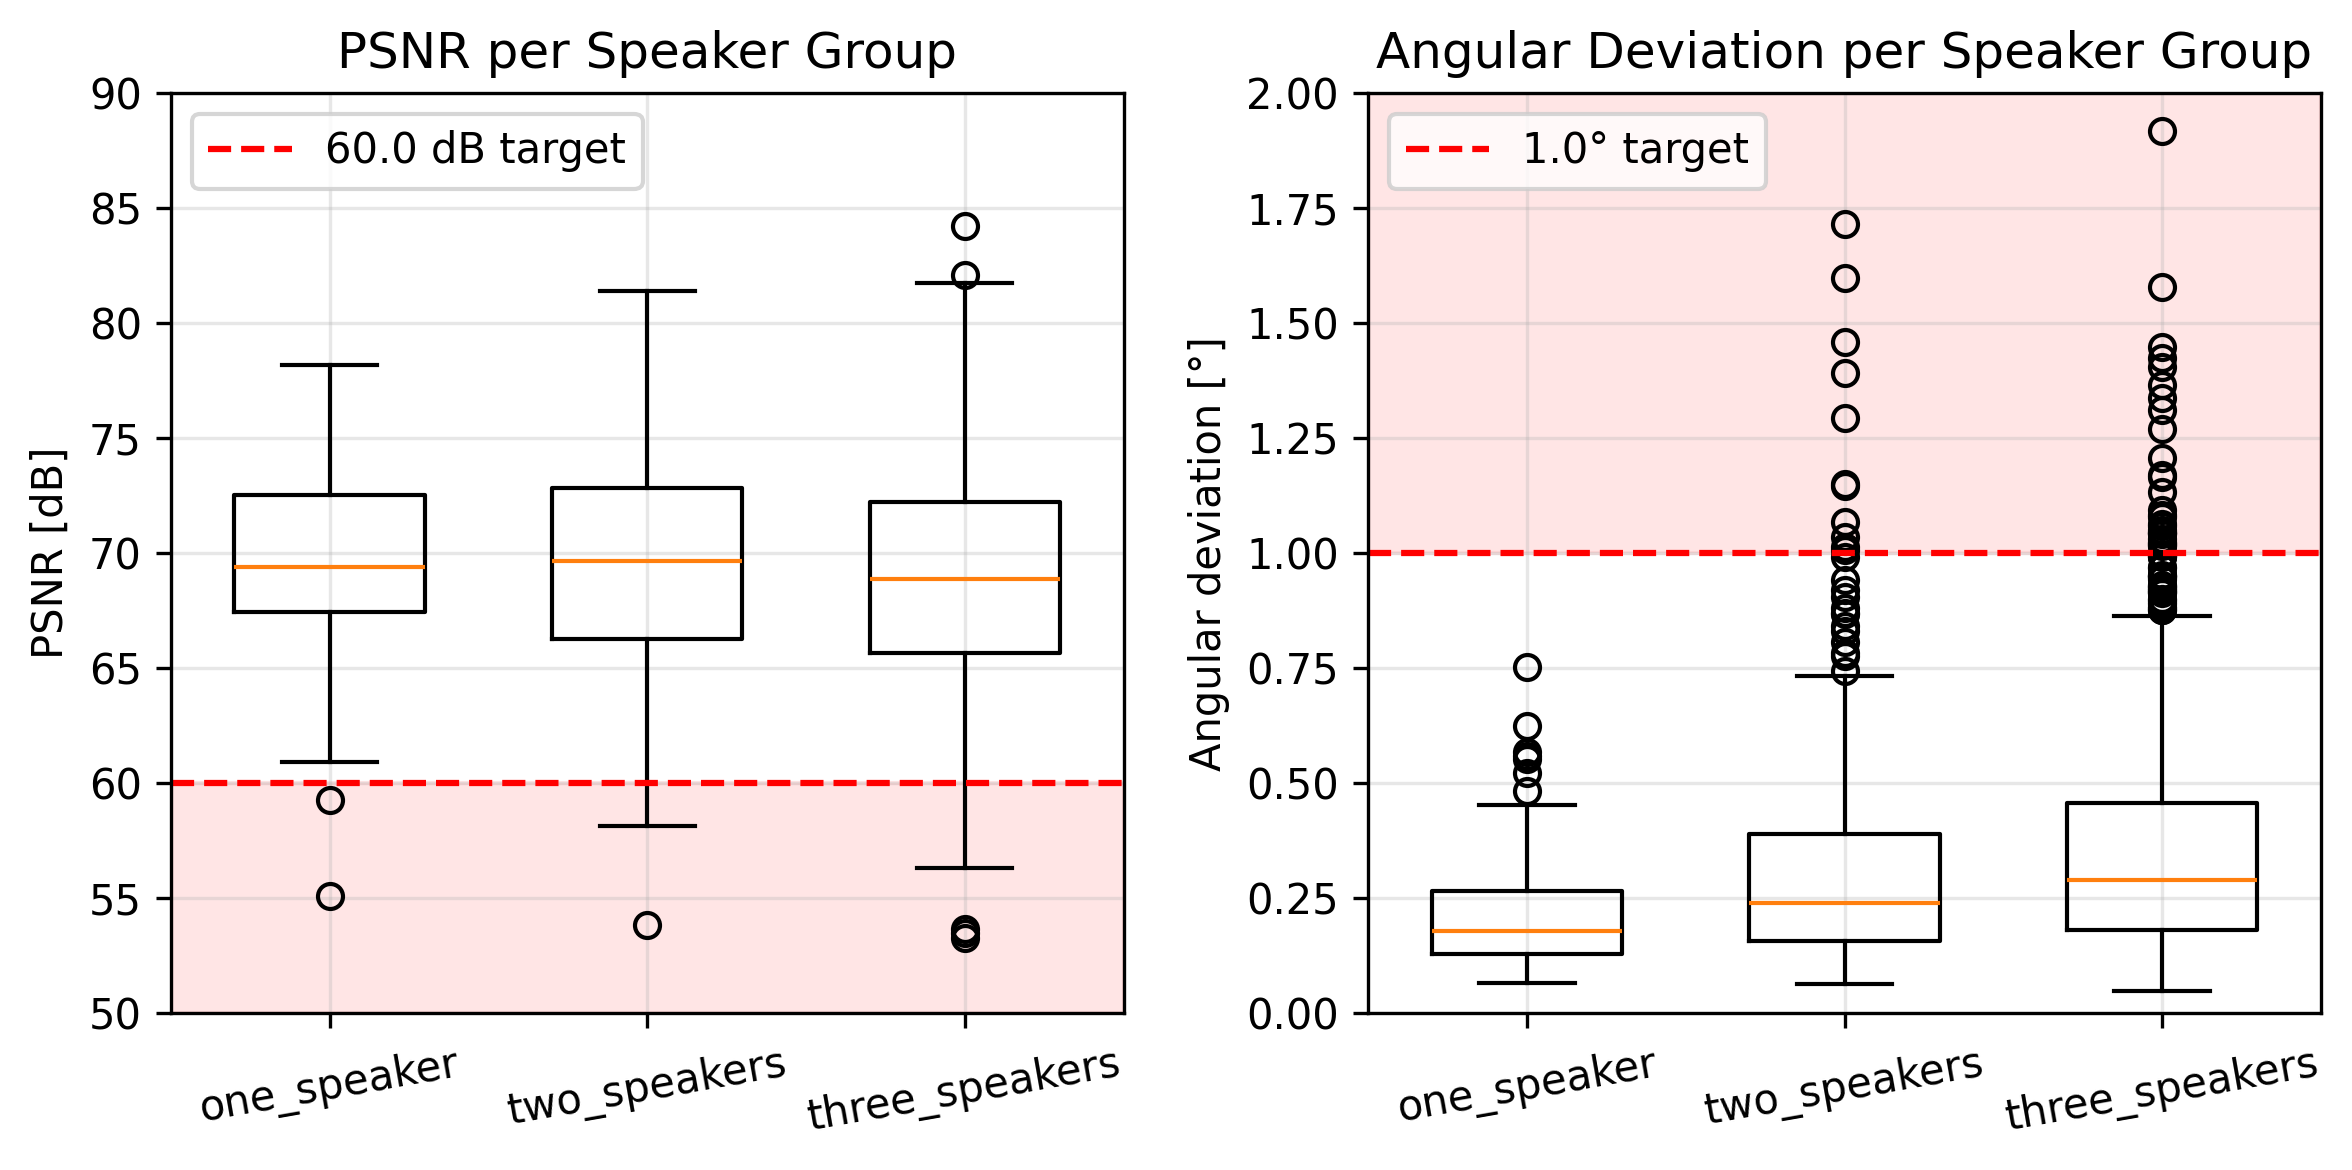

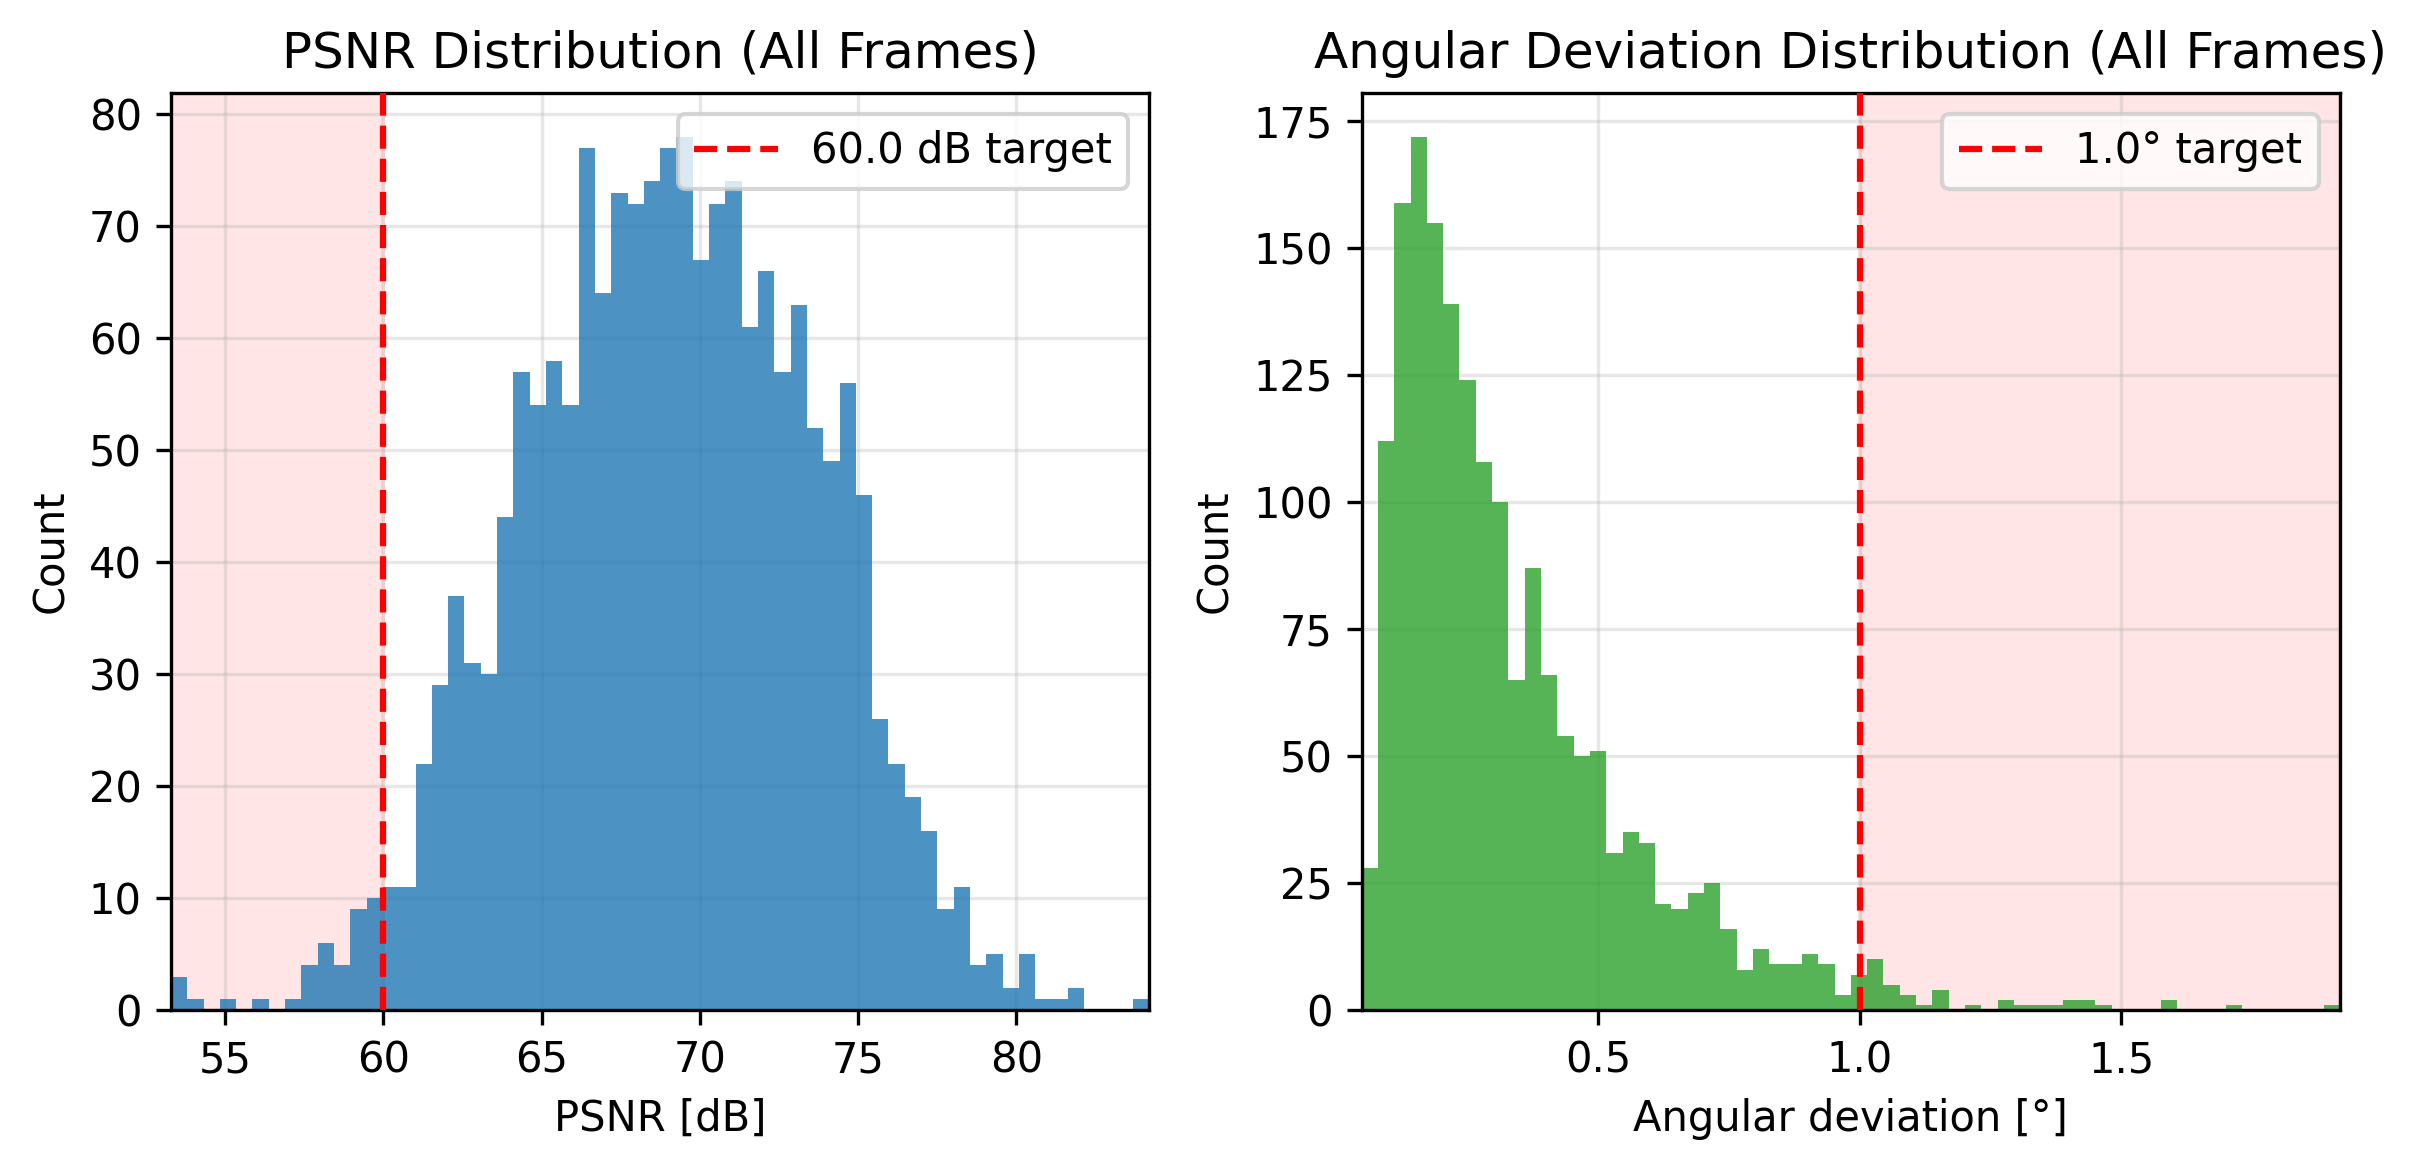

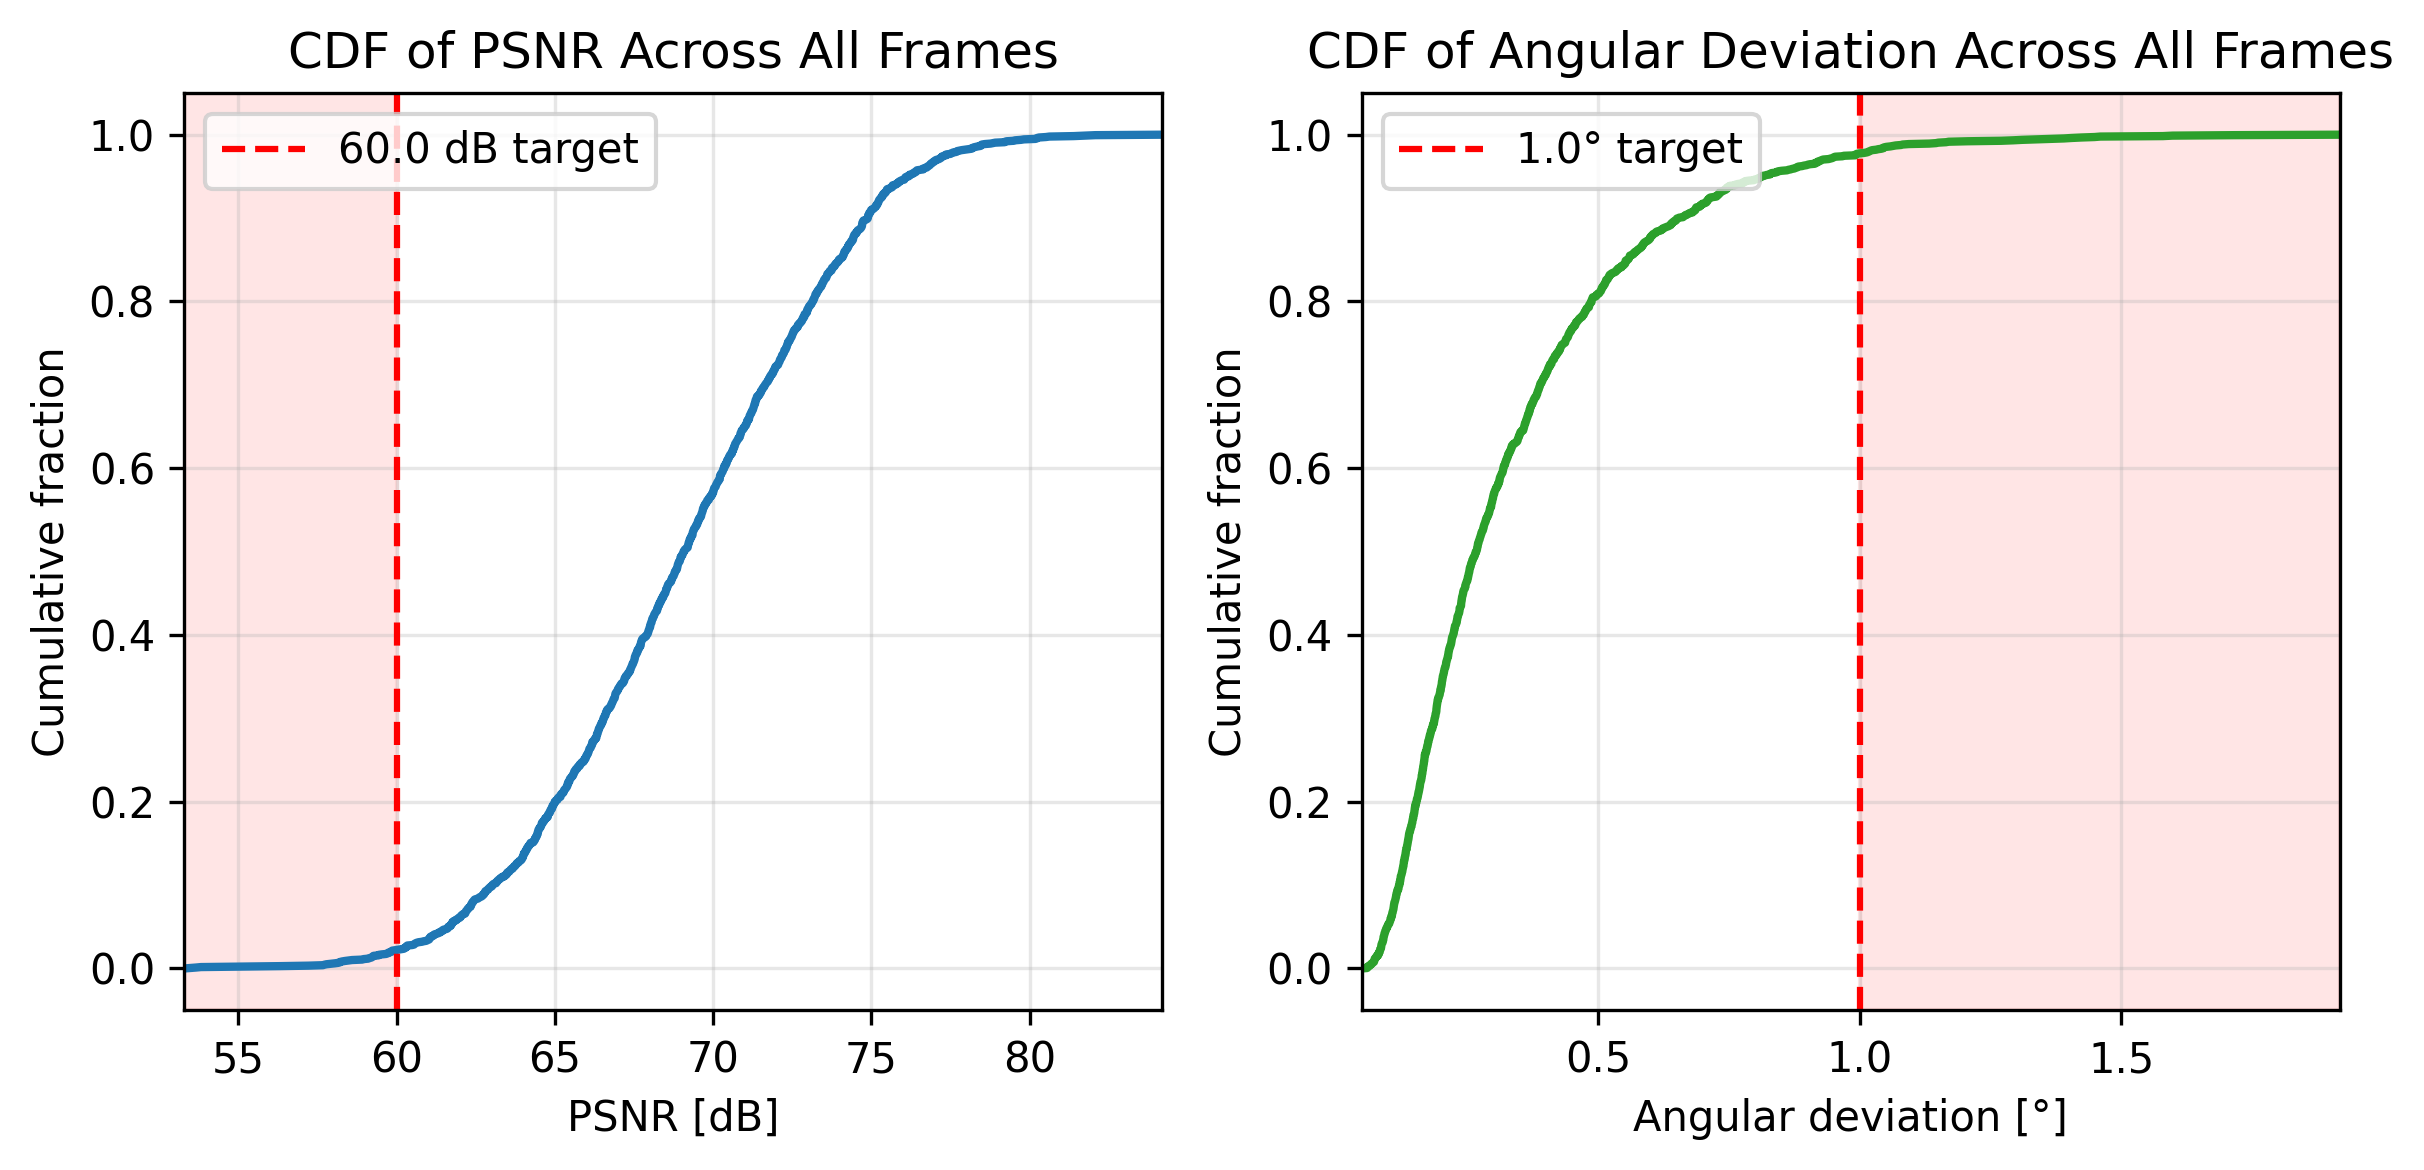

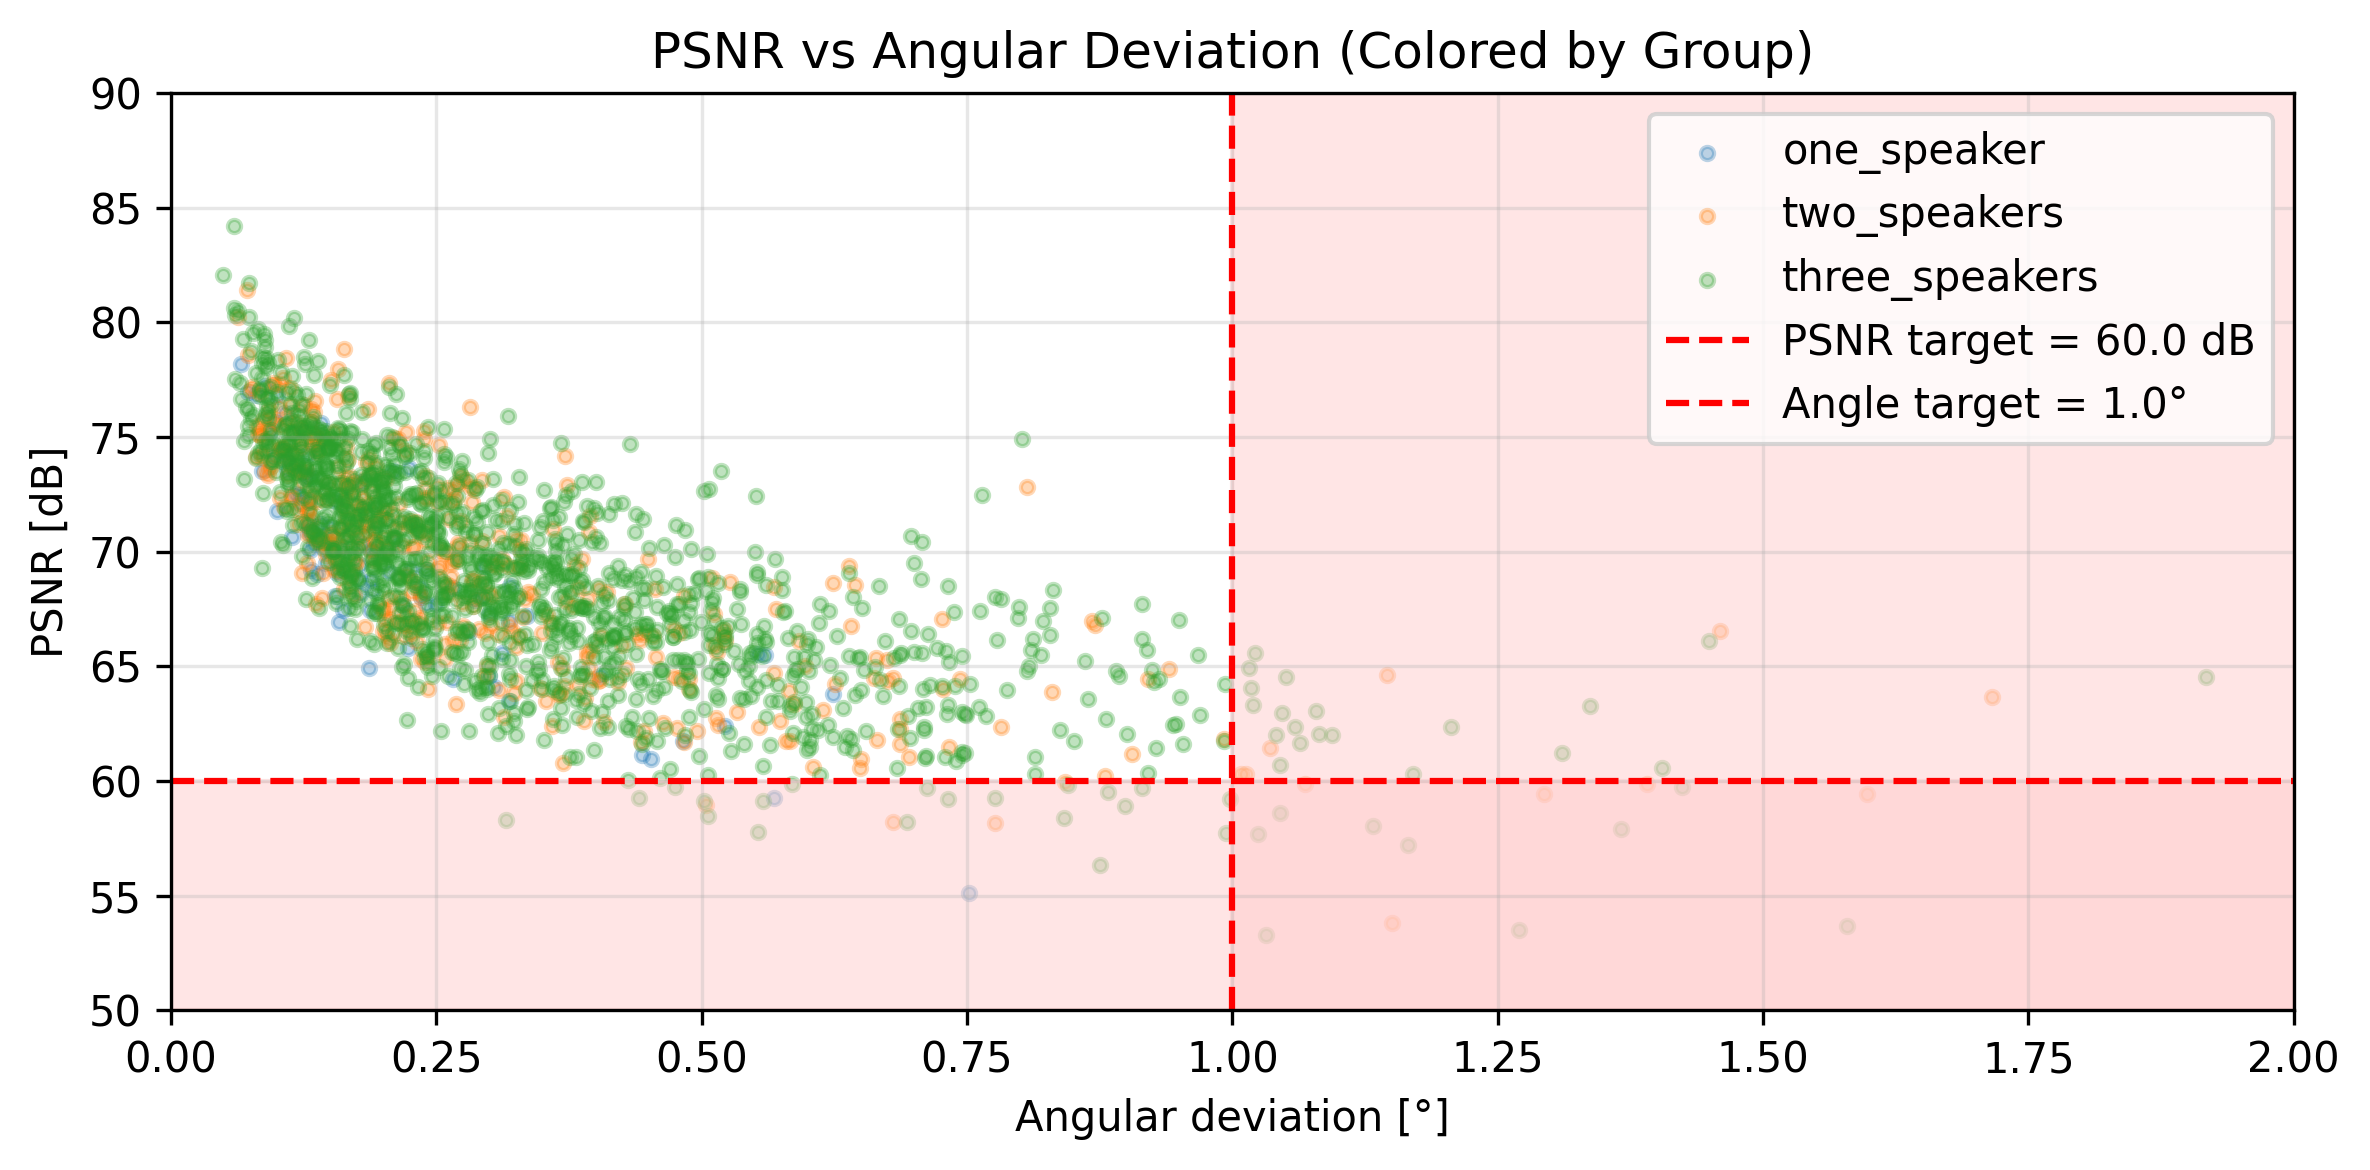

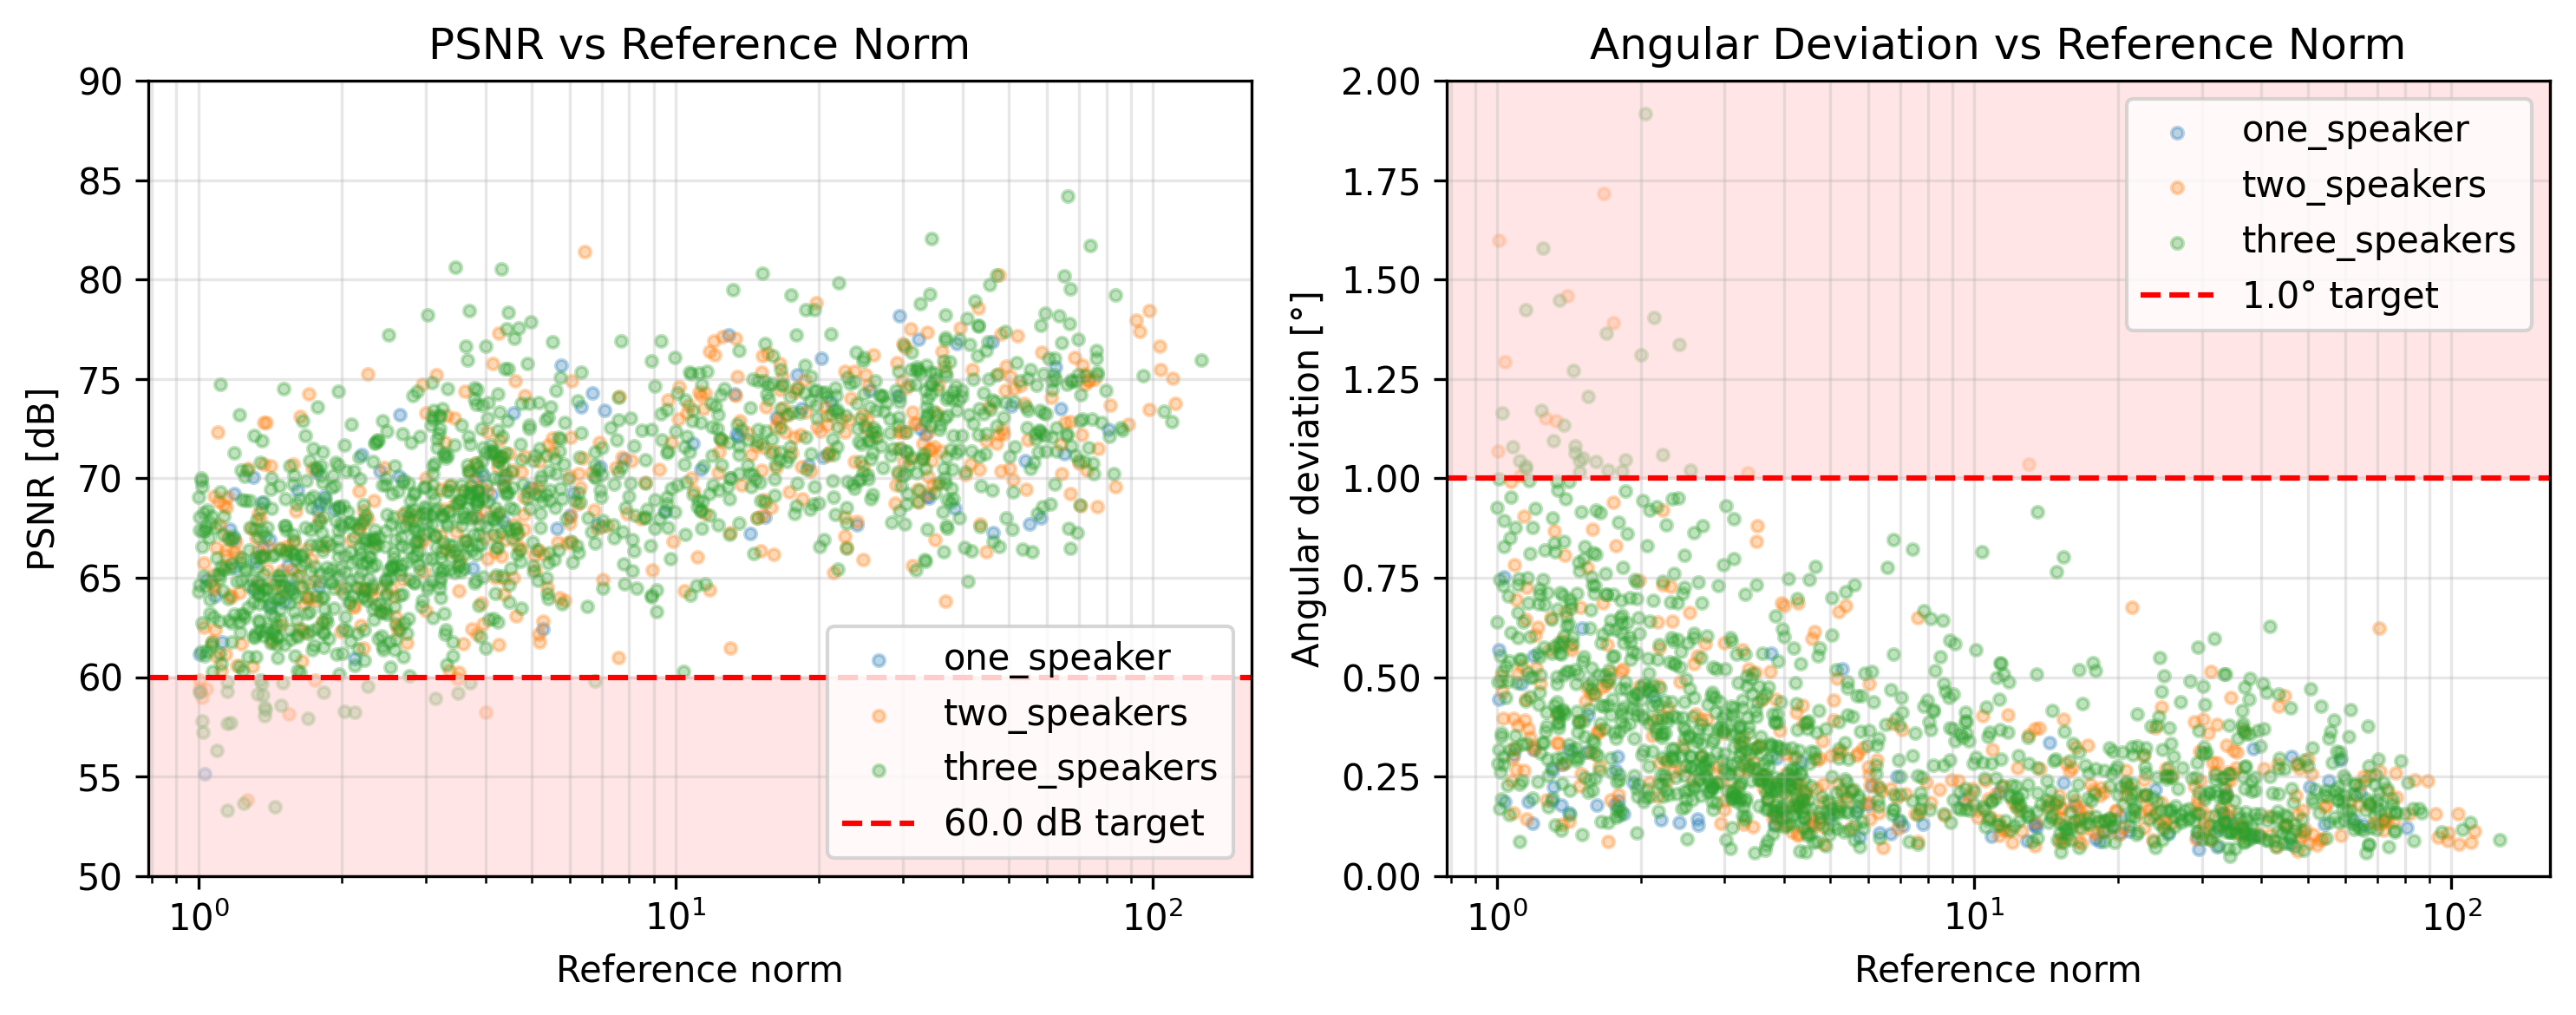

In [15]:
plt.style.use('default')

plt.rcParams.update({
    "figure.dpi": 300,
})

# Make sure groups are defined
groups = df["group"].unique()

# Convenience arrays
psnr_vals  = df["psnr_csim_ref"].values
angle_vals = df["angle_csim_ref"].values
norm_vals  = df["norm_energy"].values

PSNR_TARGET   = 60.0   # dB
ANGLE_TARGET  = 1.0    # deg

# ======================================================================
# 1. Global summary tables for PSNR and Angular Deviation
# ======================================================================

def summary_stats(x):
    return pd.Series({
        "min":       np.min(x),
        "max":       np.max(x),
        "mean":      np.mean(x),
        "median":    np.median(x),
        "5th %":     np.percentile(x, 5),
        "25th %":    np.percentile(x, 25),
        "75th %":    np.percentile(x, 75),
        "95th %":    np.percentile(x, 95),
        "99th %":    np.percentile(x, 99),
    })

psnr_summary_global  = summary_stats(psnr_vals)
angle_summary_global = summary_stats(angle_vals)

print("Global PSNR summary:")
display(psnr_summary_global.to_frame("PSNR [dB]"))

print("Global Angular Deviation summary:")
display(angle_summary_global.to_frame("Angle [deg]"))

# Target hit-rates
psnr_above_target  = (psnr_vals >= PSNR_TARGET).mean() * 100.0
angle_below_target = (angle_vals <= ANGLE_TARGET).mean() * 100.0

print(f"\nFrames with PSNR >= {PSNR_TARGET} dB: {psnr_above_target:.2f}%")
print(f"Frames with angle <= {ANGLE_TARGET}°: {angle_below_target:.2f}%")

# Frames that fail BOTH the PSNR and angle targets
fail_both_mask = (psnr_vals < PSNR_TARGET) & (angle_vals > ANGLE_TARGET)
num_fail_both  = np.sum(fail_both_mask)
pct_fail_both  = num_fail_both / len(df) * 100.0

print(f"\nFrames failing BOTH targets (PSNR < {PSNR_TARGET} dB AND angle > {ANGLE_TARGET}°):")
print(f"{num_fail_both} frames ({pct_fail_both:.2f}%)")

# Print the worst frame
worst_index_psnr = np.argmin(psnr_vals)
worst_index_angle = np.argmax(angle_vals)

print(f"\nWorst frame by PSNR {worst_index_psnr}, PSNR = {psnr_vals[worst_index_psnr]:.2f} dB, Angle = {angle_vals[worst_index_psnr]:.4f}° (recording: {df.iloc[worst_index_psnr]["recording"]})")
print(f"Worst frame by Angle {worst_index_angle}, PSNR = {psnr_vals[worst_index_angle]:.2f} dB, Angle = {angle_vals[worst_index_angle]:.4f}° (recording: {df.iloc[worst_index_angle]["recording"]})")

# Frames that REACH both targets
hit_both_mask = (psnr_vals >= PSNR_TARGET) & (angle_vals <= ANGLE_TARGET)
num_hit_both  = np.sum(hit_both_mask)
pct_hit_both  = num_hit_both / len(df) * 100.0

print(f"\nFrames REACHING BOTH targets (PSNR >= {PSNR_TARGET} dB AND angle <= {ANGLE_TARGET}°):")
print(f"{num_hit_both} frames ({pct_hit_both:.2f}%)")


# LaTeX table output

print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Global performance summary for PSNR and angular deviation.}")
print(r"\begin{tabular}{lcc}")
print(r"\toprule")
print(r"\textbf{Statistic} & \textbf{PSNR [dB]} & \textbf{Angle [deg]} \\")
print(r"\midrule")

stats = [
    ("Minimum",        "min"),
    ("Maximum",        "max"),
    ("Mean",           "mean"),
    ("Median",         "median"),
    ("5th percentile", "5th %"),
    ("25th percentile","25th %"),
    ("75th percentile","75th %"),
    ("95th percentile","95th %"),
    ("99th percentile","99th %"),
]

for label, key in stats:
    psnr_val  = psnr_summary_global[key]
    angle_val = angle_summary_global[key]
    print(f"{label} & {psnr_val:.2f} & {angle_val:.4f} \\\\")

print(r"\midrule")

# NORMAL target hit row (two columns as before)
print(f"Target hit rate & {psnr_above_target:.2f}\\% & {angle_below_target:.2f}\\% \\\\")

# MERGED CELLS for both-targets and none-targets rows
print(
    r"Hit \textbf{both} targets & \multicolumn{2}{c}{"
    f"{pct_hit_both:.2f}\\%}} \\\\"
)

print(
    r"Hit \textbf{no} targets & \multicolumn{2}{c}{"
    f"{pct_fail_both:.2f}\\%}} \\\\"
)

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\label{tab:accuracy_results_summary}")
print(r"\end{table}")




# ======================================================================
# 2. Per-group summary table (PSNR + Angle)
# ======================================================================

rows = []
for g in groups:
    mask = (df["group"] == g)
    psnr_g  = psnr_vals[mask]
    angle_g = angle_vals[mask]
    row = {
        "group": g,
        "PSNR_mean":   np.mean(psnr_g),
        "PSNR_median": np.median(psnr_g),
        "PSNR_5%":     np.percentile(psnr_g, 5),
        "PSNR_95%":    np.percentile(psnr_g, 95),
        f"%_PSNR>={PSNR_TARGET}": (psnr_g >= PSNR_TARGET).mean() * 100.0,
        "ANG_mean":    np.mean(angle_g),
        "ANG_median":  np.median(angle_g),
        "ANG_95%":     np.percentile(angle_g, 95),
        "ANG_99%":     np.percentile(angle_g, 99),
        f"%_ANG<={ANGLE_TARGET}": (angle_g <= ANGLE_TARGET).mean() * 100.0,
    }
    fail_both_g = np.sum((psnr_g < PSNR_TARGET) & (angle_g > ANGLE_TARGET))
    hit_both_g  = np.sum((psnr_g >= PSNR_TARGET) & (angle_g <= ANGLE_TARGET))

    row["#_fail_both"] = fail_both_g
    row["%_fail_both"] = fail_both_g / len(psnr_g) * 100.0

    row["#_hit_both"]  = hit_both_g
    row["%_hit_both"]  = hit_both_g / len(psnr_g) * 100.0

    rows.append(row)

group_summary = pd.DataFrame(rows)
print("\nPer-group PSNR and Angular Deviation summary:")
display(group_summary)

# ======================================================================
# 3. Boxplots: PSNR per group
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# convenience data ranges (used for shading)
psnr_min, psnr_max = 50, 90
angle_min, angle_max = 0, 2

# PSNR boxplot (use patch_artist so boxes can be colored)
data_psnr = [df[df["group"] == g]["psnr_csim_ref"] for g in groups]
bp_psnr = axes[0].boxplot(data_psnr, labels=groups, widths=0.6)
axes[0].axhline(PSNR_TARGET, color="red", linestyle="--", label=f"{PSNR_TARGET} dB target")
# shade failing side (PSNR below target)
axes[0].axhspan(psnr_min, PSNR_TARGET, color="#ffcccc", alpha=0.5, zorder=1)
axes[0].set_ylim(psnr_min, psnr_max)
axes[0].set_title("PSNR per Speaker Group")
axes[0].set_ylabel("PSNR [dB]")
axes[0].tick_params(axis="x", rotation=10)
axes[0].grid(alpha=0.3)
axes[0].legend(loc= "upper left")

# Angular deviation boxplot (patch_artist for coloring)
data_ang = [df[df["group"] == g]["angle_csim_ref"] for g in groups]
bp_ang = axes[1].boxplot(data_ang, labels=groups, widths=0.6)
axes[1].axhline(ANGLE_TARGET, color="red", linestyle="--", label=f"{ANGLE_TARGET}° target")
# shade failing side (angle above target)
axes[1].set_ylim(angle_min, angle_max)
axes[1].axhspan(ANGLE_TARGET, angle_max, color="#ffcccc", alpha=0.5, zorder=1)
axes[1].set_title("Angular Deviation per Speaker Group")
axes[1].set_ylabel("Angular deviation [°]")
axes[1].tick_params(axis="x", rotation=10)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(
    r"C:\Users\bramh\OneDrive\Documenten\Studie\Thesis\Figures\accuracy_boxplot_speakergrouping.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# ======================================================================
# 5-6. Histograms: PSNR and Angular deviation combined in one figure
# ======================================================================

fig_hist, axes_hist = plt.subplots(1, 2, figsize=(8, 4))

psnr_min, psnr_max = np.min(psnr_vals), np.max(psnr_vals)
angle_min, angle_max = np.min(angle_vals), np.max(angle_vals)

# PSNR histogram (force range to data min/max so no extra whitespace)
n_psnr, bins_psnr, patches_psnr = axes_hist[0].hist(
    psnr_vals, bins=60, range=(psnr_min, psnr_max),
    color="tab:blue", alpha=0.8, zorder=2
)
axes_hist[0].axvline(PSNR_TARGET, color="red", linestyle="--",
                     label=f"{PSNR_TARGET} dB target", zorder=3)
axes_hist[0].set_title("PSNR Distribution (All Frames)")
axes_hist[0].set_xlabel("PSNR [dB]")
axes_hist[0].set_ylabel("Count")
axes_hist[0].grid(alpha=0.3)
# shade failing side (PSNR below target)
fail_left, fail_right = psnr_min, min(PSNR_TARGET, psnr_max)
if fail_right > fail_left:
    axes_hist[0].axvspan(fail_left, fail_right, color="#ffcccc", alpha=0.5, zorder=1)
# explicitly bound x-axis to data limits (no leading/trailing whitespace)
axes_hist[0].set_xlim(psnr_min, psnr_max)
axes_hist[0].legend()

# Angle histogram (force range to data min/max so no extra whitespace)
n_ang, bins_ang, patches_ang = axes_hist[1].hist(
    angle_vals, bins=60, range=(angle_min, angle_max),
    color="tab:green", alpha=0.8, zorder=2
)
axes_hist[1].axvline(ANGLE_TARGET, color="red", linestyle="--",
                     label=f"{ANGLE_TARGET}° target", zorder=3)
axes_hist[1].set_title("Angular Deviation Distribution (All Frames)")
axes_hist[1].set_xlabel("Angular deviation [°]")
axes_hist[1].set_ylabel("Count")
axes_hist[1].grid(alpha=0.3)
# shade failing side (angle above target)
fail_left, fail_right = max(ANGLE_TARGET, angle_min), angle_max
if fail_right > fail_left:
    axes_hist[1].axvspan(fail_left, fail_right, color="#ffcccc", alpha=0.5, zorder=1)
# explicitly bound x-axis to data limits (no leading/trailing whitespace)
axes_hist[1].set_xlim(angle_min, angle_max)
axes_hist[1].legend()

plt.tight_layout()
plt.savefig(
    r"C:\Users\bramh\OneDrive\Documenten\Studie\Thesis\Figures\accuracy_histogram_allframes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# ======================================================================
# 7-8. CDFs: PSNR and Angular deviation combined in one figure
# ======================================================================

psnr_sorted  = np.sort(psnr_vals)
cdf_psnr     = np.linspace(0, 1, len(psnr_sorted))

angle_sorted = np.sort(angle_vals)
cdf_angle    = np.linspace(0, 1, len(angle_sorted))

psnr_min, psnr_max   = np.min(psnr_vals), np.max(psnr_vals)
angle_min, angle_max = np.min(angle_vals), np.max(angle_vals)

fig_cdf, axes_cdf = plt.subplots(1, 2, figsize=(8, 4))

# --------------------------------------------------
# PSNR CDF
# --------------------------------------------------
axes_cdf[0].plot(psnr_sorted, cdf_psnr, linewidth=2, color="tab:blue")
axes_cdf[0].axvline(PSNR_TARGET, color="red", linestyle="--",
                    label=f"{PSNR_TARGET} dB target")

# Shade failing area (PSNR < target)
fail_left, fail_right = psnr_min, min(PSNR_TARGET, psnr_max)
if fail_right > fail_left:
    axes_cdf[0].axvspan(fail_left, fail_right, color="#ffcccc", alpha=0.5, zorder=1)

axes_cdf[0].set_xlim(psnr_min, psnr_max)
axes_cdf[0].set_xlabel("PSNR [dB]")
axes_cdf[0].set_ylabel("Cumulative fraction")
axes_cdf[0].set_title("CDF of PSNR Across All Frames")
axes_cdf[0].grid(alpha=0.3)
axes_cdf[0].legend(loc="upper left")


# --------------------------------------------------
# Angle CDF
# --------------------------------------------------
axes_cdf[1].plot(angle_sorted, cdf_angle, linewidth=2, color="tab:green")
axes_cdf[1].axvline(ANGLE_TARGET, color="red", linestyle="--",
                    label=f"{ANGLE_TARGET}° target")

# Shade failing area (angle > target)
fail_left, fail_right = max(ANGLE_TARGET, angle_min), angle_max
if fail_right > fail_left:
    axes_cdf[1].axvspan(fail_left, fail_right, color="#ffcccc", alpha=0.5, zorder=1)

axes_cdf[1].set_xlim(angle_min, angle_max)
axes_cdf[1].set_xlabel("Angular deviation [°]")
axes_cdf[1].set_ylabel("Cumulative fraction")
axes_cdf[1].set_title("CDF of Angular Deviation Across All Frames")
axes_cdf[1].grid(alpha=0.3)
axes_cdf[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig(
    r"C:\Users\bramh\OneDrive\Documenten\Studie\Thesis\Figures\accuracy_cdfs_allframes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ======================================================================
# 9. Scatter: PSNR vs Angular Deviation (colored by group)
# With fixed boxplot limits + shading + target labels
# ======================================================================

# Fixed limits from boxplots
psnr_min, psnr_max = 50, 90
angle_min, angle_max = 0, 2

plt.figure(figsize=(8, 4))

for g in groups:
    mask = (df["group"] == g)
    plt.scatter(
        df.loc[mask, "angle_csim_ref"],
        df.loc[mask, "psnr_csim_ref"],
        s=10,
        alpha=0.3,
        label=g,
        # color=colors.get(g, None),
    )

# ---------------------------------------------------------------------
# Target lines
# ---------------------------------------------------------------------
plt.axhline(PSNR_TARGET, color="red", linestyle="--",
            label=f"PSNR target = {PSNR_TARGET} dB")
plt.axvline(ANGLE_TARGET, color="red", linestyle="--",
            label=f"Angle target = {ANGLE_TARGET}°")

# ---------------------------------------------------------------------
# Shaded failing regions (consistent with all other plots)
# ---------------------------------------------------------------------

# Failing PSNR region (below target)
psnr_fail_low  = psnr_min
psnr_fail_high = min(PSNR_TARGET, psnr_max)
if psnr_fail_high > psnr_fail_low:
    plt.axhspan(psnr_fail_low, psnr_fail_high,
                color="#ffcccc", alpha=0.5, zorder=1)

# Failing Angle region (above target)
ang_fail_low  = max(ANGLE_TARGET, angle_min)
ang_fail_high = angle_max
if ang_fail_high > ang_fail_low:
    plt.axvspan(ang_fail_low, ang_fail_high,
                color="#ffcccc", alpha=0.5, zorder=1)

# ---------------------------------------------------------------------
# Axes
# ---------------------------------------------------------------------
plt.xlim(angle_min, angle_max)
plt.ylim(psnr_min, psnr_max)

plt.xlabel("Angular deviation [°]")
plt.ylabel("PSNR [dB]")
plt.title("PSNR vs Angular Deviation (Colored by Group)")

plt.grid(alpha=0.3)
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(
    r"C:\Users\bramh\OneDrive\Documenten\Studie\Thesis\Figures\accuracy_scatter_psnr_vs_angulardev.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()




# ======================================================================
# 10–11. Scatter: PSNR/Angle vs Reference Norm (colored by group, log norm)
# Combined horizontally with SAME y-limits as boxplots + shading logic
# ======================================================================

# Use same fixed boxplot limits
psnr_min, psnr_max = 50, 90
angle_min, angle_max = 0, 2

norm_min, norm_max = np.min(norm_vals), np.max(norm_vals)

fig_scatter, axes_scatter = plt.subplots(1, 2, figsize=(10, 4))

# -------------------------------------------------------------
# Left: PSNR vs Reference Norm
# -------------------------------------------------------------
for g in groups:
    mask = (df["group"] == g)
    axes_scatter[0].scatter(
        df.loc[mask, "norm_energy"],
        df.loc[mask, "psnr_csim_ref"],
        s=10,
        alpha=0.3,
        label=g,
        # color=colors.get(g, None),
    )

# Target line
axes_scatter[0].axhline(PSNR_TARGET, color="red", linestyle="--",
                        label=f"{PSNR_TARGET} dB target")

# Shaded failing region (PSNR < target)
fail_low  = psnr_min
fail_high = min(PSNR_TARGET, psnr_max)
if fail_high > fail_low:
    axes_scatter[0].axhspan(fail_low, fail_high,
                            color="#ffcccc", alpha=0.5, zorder=1)

axes_scatter[0].set_xscale("log")
# axes_scatter[0].set_xlim(norm_min, norm_max)
axes_scatter[0].set_ylim(psnr_min, psnr_max)     # <-- BOX­PLOT RANGE
axes_scatter[0].set_xlabel("Reference norm")
axes_scatter[0].set_ylabel("PSNR [dB]")
axes_scatter[0].set_title("PSNR vs Reference Norm")
axes_scatter[0].grid(alpha=0.3, which="both")
axes_scatter[0].legend()


# -------------------------------------------------------------
# Right: Angular deviation vs Reference Norm
# -------------------------------------------------------------
for g in groups:
    mask = (df["group"] == g)
    axes_scatter[1].scatter(
        df.loc[mask, "norm_energy"],
        df.loc[mask, "angle_csim_ref"],
        s=10,
        alpha=0.3,
        label=g,
        # color=colors.get(g, None),
    )

# Target line
axes_scatter[1].axhline(ANGLE_TARGET, color="red", linestyle="--",
                        label=f"{ANGLE_TARGET}° target")

# Shaded failing region (angle > target)
fail_low  = max(ANGLE_TARGET, angle_min)
fail_high = angle_max
if fail_high > fail_low:
    axes_scatter[1].axhspan(fail_low, fail_high,
                            color="#ffcccc", alpha=0.5, zorder=1)

axes_scatter[1].set_xscale("log")
# axes_scatter[1].set_xlim(norm_min, norm_max)
axes_scatter[1].set_ylim(angle_min, angle_max)   # <-- BOX­PLOT RANGE
axes_scatter[1].set_xlabel("Reference norm")
axes_scatter[1].set_ylabel("Angular deviation [°]")
axes_scatter[1].set_title("Angular Deviation vs Reference Norm")
axes_scatter[1].grid(alpha=0.3, which="both")
axes_scatter[1].legend()

plt.tight_layout()
plt.savefig(
    r"C:\Users\bramh\OneDrive\Documenten\Studie\Thesis\Figures\accuracy_scatter_vs_norm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


